In [1]:
import json

import numpy as np
import pandas as pd
from pandas.core.common import random_state
from sklearn.model_selection import train_test_split

import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import v2
import torch.nn as nn

In [2]:
path_to_labels = '../cassava-leaf-disease-classification/train.csv'

df = pd.read_csv(path_to_labels) # Read the labels

In [3]:
# Forming 80/10/10 train, validate, test splits

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

# Ensuring batches are disjoint from one another and that all batches add up to 100%

assert len(train_df) + len(val_df) + len(test_df) == len(df)

assert set(train_df.index).isdisjoint(val_df.index)
assert set(train_df.index).isdisjoint(test_df.index)
assert set(val_df.index).isdisjoint(test_df.index)

In [4]:
class CassavaDataset(Dataset):
    """
    Initializing the dataset structure, this class inherits torch.utils.data.Dataset.
    The __init__ method will define the attributes of the dataset, and initialize any transformation needed.
    __len__ will return the number of images in the dataset. Finally, __getitem__ will get the label and image being requested.
    Once retrieved, the image will undergo any needed transformation. Once transformations are done, return the image and label.
    """
    def __init__(self, df, image_dir, transform=None, return_path=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.return_path = return_path

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = os.path.join(self.image_dir, row["image_id"])

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        if self.return_path:
            return image, label, image_path

        return image, label


In [5]:
train_transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.uint8, scale=False)])
val_transform = None
test_transform = None

image_dir = '../cassava-leaf-disease-classification/train_images'

train_dataset = CassavaDataset(train_df, image_dir, train_transform, return_path=True)
val_dataset = CassavaDataset(val_df, image_dir, val_transform)
test_dataset = CassavaDataset(test_df, image_dir, test_transform)

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
import matplotlib.pyplot as plt

images, labels, file_path = next(iter(train_loader))

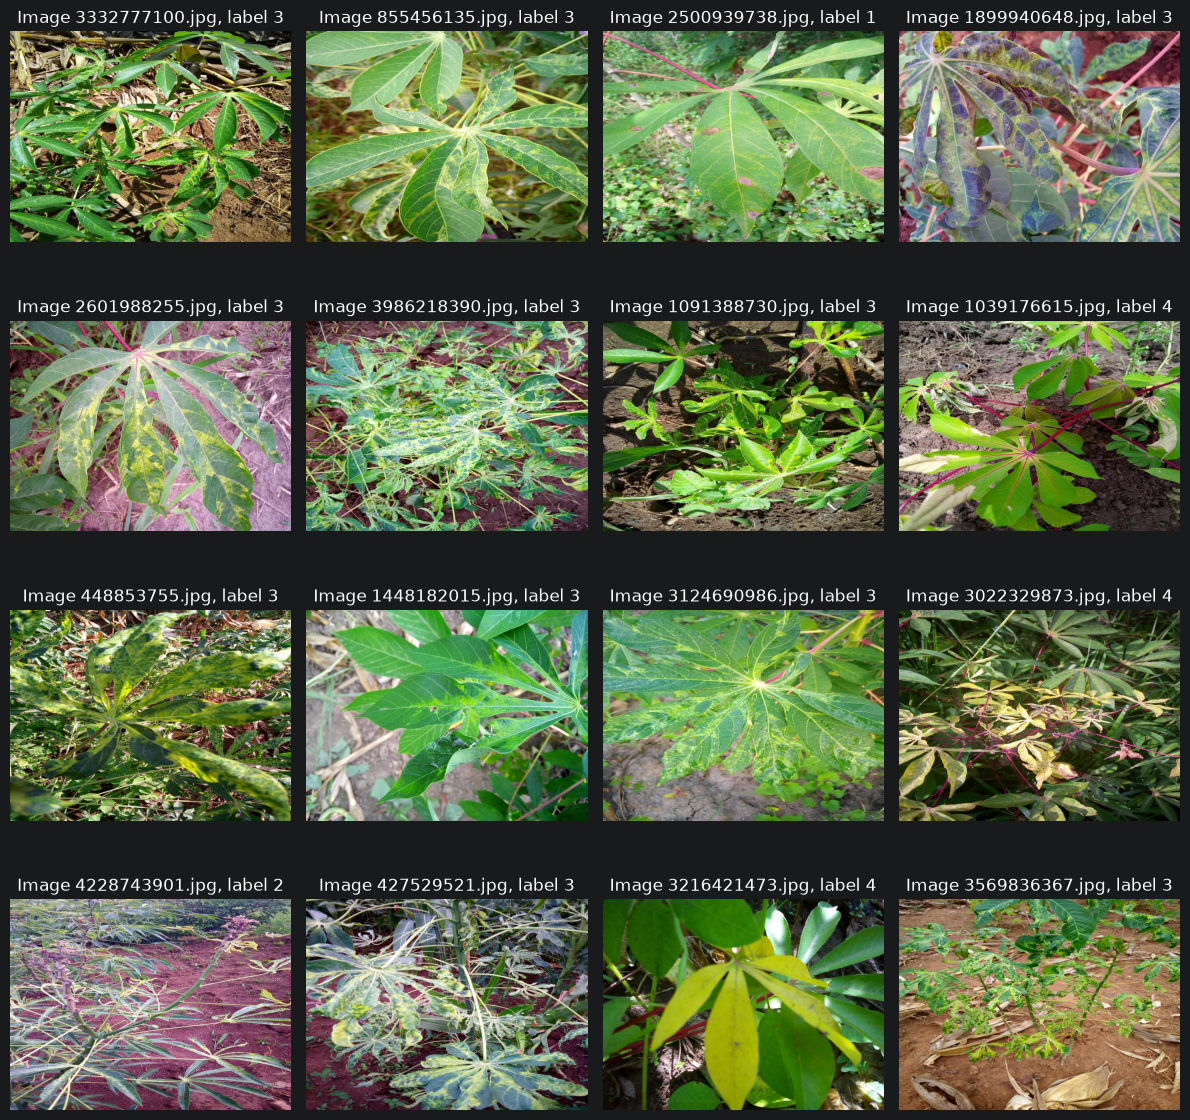

In [8]:
fig, axs = plt.subplots(4, 4, figsize=(12, 12))

for i in range(4):
    for j in range(4):
        idx = (i * 4) + j
        im = images[idx, ...].permute(1, 2, 0).numpy()
        axs[i, j].imshow(im)
        axs[i, j].axis('off')
        axs[i, j].set_title(f"Image {str(file_path[idx].split("/")[-1])}, label {str(labels[idx].item())}")

plt.tight_layout()
plt.show()

In [9]:
print(f"General Statistics:\n++++++++++++++++++++++++++++++++++++++++=\n"
      f"Heigh of Images: {images.shape[2]}\n"
      f"Width of Images: {images.shape[3]}\n"
      f"Number of Images in Train: {len(train_dataset)}\n"
      f"Number of Images in Validation: {len(val_dataset)}\n"
      f"Number of Images in Test: {len(test_dataset)}\n")

General Statistics:
++++++++++++++++++++++++++++++++++++++++=
Heigh of Images: 600
Width of Images: 800
Number of Images in Train: 17117
Number of Images in Validation: 2140
Number of Images in Test: 2140



In [23]:
'''
Initializing the ResNet-18 model with default weights.
'''

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

In [11]:
model.fc # Cassava has 5 output classes, look at how many the default model has!

Linear(in_features=512, out_features=1000, bias=True)

In [24]:
for param in model.parameters():
    param.requires_grad = False # Freezing the backbone

# Updating the full-connected layer to have the correct number of output classes.
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

print(model.fc) # Look at the difference!
print(weights.transforms()) # This also gives default values for the

Linear(in_features=512, out_features=5, bias=True)
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [13]:
'''
Let's look at the structure of the model.


'''

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [14]:
# Setting up transformation initial test

train_transform = v2.Compose([
    v2.RandomResizedCrop(224, scale=(0.8, 1.0)), # Cropping random portion of the input and resizing it. Scale gives lower and upper bound for the crop area
    v2.RandomHorizontalFlip(), # 50% probability that an image is horizontally flipped
    v2.RandomRotation(degrees=15), # Rotates every image by a random degree from [-15, +15]
    v2.ColorJitter( # Randomly changes the brightnes, contrast, saturation of an image
        brightness=0.1, # Brightness factor is jittered uniformly between [max(0, 1-[0.1]), 1 + [0.1]]
        contrast=0.1, # Contrast factor is jittered uniformly between [max(0, 1-[0.1], (1 + [0.1])]
        saturation=0.1, # Saturation factor is jittered uniformly between [max(0, 1-[0.1]), (1+ [0.1])]
    ),
    v2.ToImage(), # Make image a tensor
    v2.ToDtype(torch.float32, scale=True), # Converts image to have datatype float32. We use float32 rather than uint8 since the network needs floating point numbers to correctly operate. Scale move the image from [0, 225] (default uint8 for JPEG) -> [0, 1]
    v2.Normalize(
        mean=[0.485, 0.456, 0.406], # Mean & Std come directly from the ResNet-18 default models
        std=[0.229, 0.224, 0.225]
    )
])

'''
We have two types of transformations here: data augmentation and required preprocessing.

Data augmentation is used to improve generalization and can be experimented with. These steps include the crop, flip, rotation, and jitter methods above.

Required preprocessing is used to ensure the pretrained model can satisfy it's assumptions. These preprocessing steps are fairly fixed in place as we move on with the training stage. These steps include the float32 conversion, normalization, and ensureing we have the correct expected dimension from the methods above.
'''

# Setting up validation transformation

val_transform = v2.Compose([
    v2.Resize(256), # Rescaling to (256 * height/width, 256)
    v2.CenterCrop(224), # Crops the image to size (224x224)
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Updating datasets and dataloaders with the transformations
train_dataset = CassavaDataset(train_df, image_dir, train_transform, return_path=True)
val_dataset = CassavaDataset(val_df, image_dir, val_transform, return_path=True)

# Loading the data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.1694121].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..1.9558825].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.2739873].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831376].

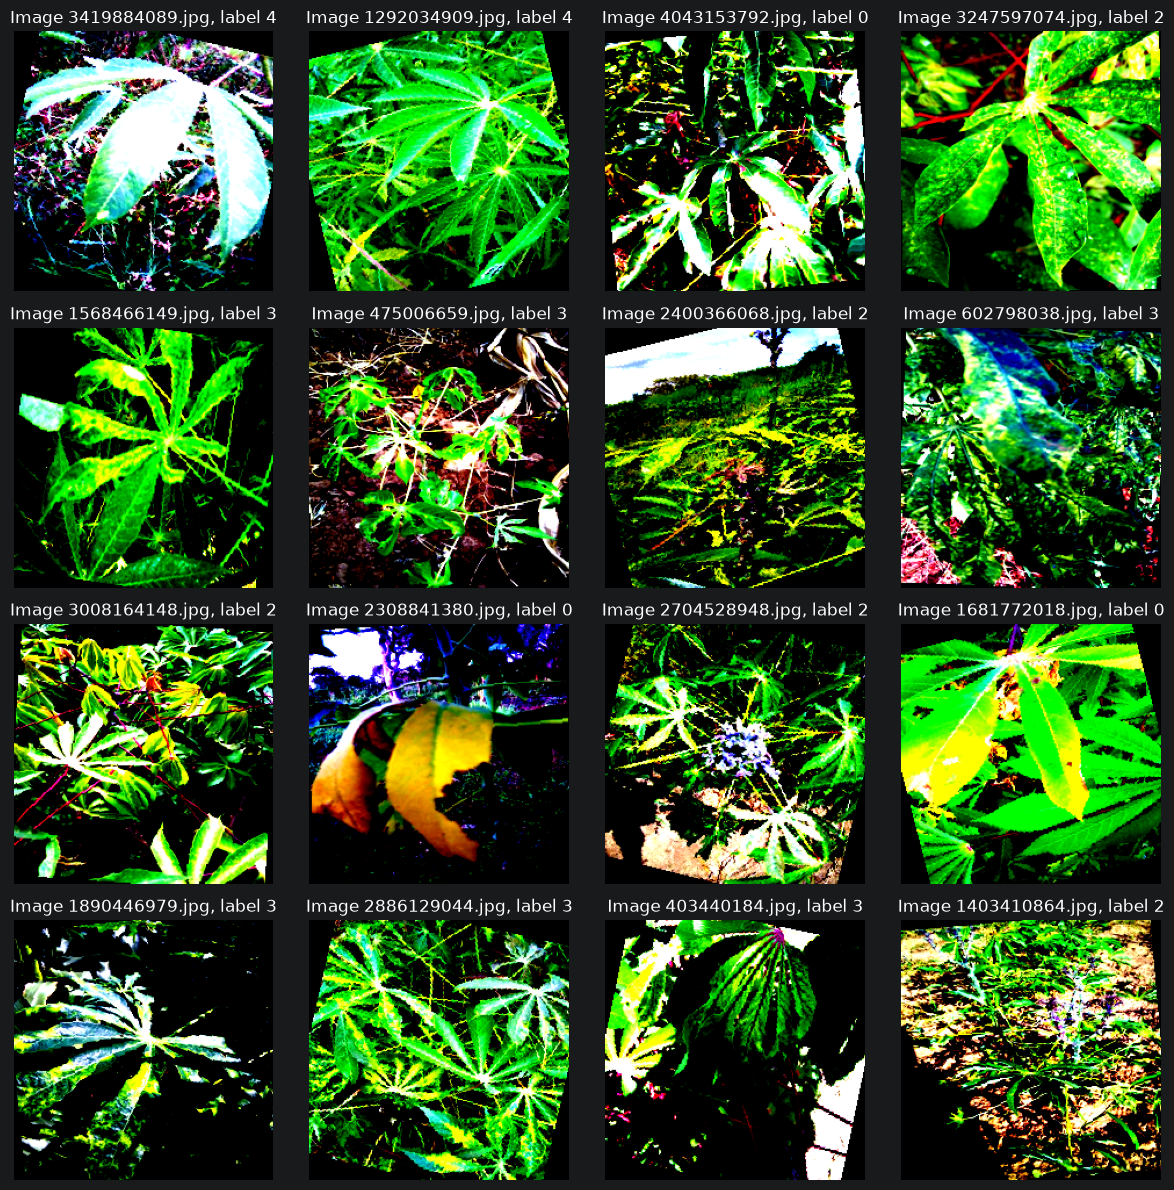

In [15]:
images, labels, file_path = next(iter(train_loader))

fig, axs = plt.subplots(4, 4, figsize=(12, 12))

for i in range(4):
    for j in range(4):
        idx = (i * 4) + j
        im = images[idx, ...].permute(1, 2, 0).numpy()
        axs[i, j].imshow(im)
        axs[i, j].axis('off')
        axs[i, j].set_title(f"Image {str(file_path[idx].split("/")[-1])}, label {str(labels[idx].item())}")

plt.tight_layout()
plt.show()

In [55]:
# Model Rest

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

In [56]:
# Updating datasets and dataloaders with the transformations
train_dataset = CassavaDataset(train_df, image_dir, train_transform)
val_dataset = CassavaDataset(val_df, image_dir, val_transform)

# Loading the data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [57]:
lr = 1e-3
epochs = 1

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=lr
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

Using device: cuda


In [60]:
def training_loop(dataloader, model, loss_fn, optimizer, accuracy_tracker = None, loss_tracker = None):
    size = len(dataloader.dataset)
    model.train()
    loss_holder = []

    num_correct = 0
    num_seen = 0

    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        pred = model(X)
        loss = loss_fn(pred, y)
        loss_holder.append(loss.item())

        loss.backward()
        optimizer.step()

        pred_class = pred.argmax(dim=1)
        num_correct += (pred_class == y).sum().item()
        num_seen += y.size(0)

        if batch % 100 == 0:
            loss, current = loss.item(), min((batch + 1) * dataloader.batch_size, size)
            print(f"BATCH {batch} -> loss {loss:7f}  [{current:>5f}/{size:>5d}]")

    if accuracy_tracker is not None:
        accuracy = num_correct / num_seen
        accuracy_tracker.append(accuracy)

    if loss_tracker is not None:
        avg_loss = np.mean(loss_holder)
        loss_tracker.append(avg_loss)

def validation_loop(dataloader, model, loss_fn, accuracy_tracker = None, loss_tracker = None):
    size = len(dataloader.dataset)
    model.eval()

    loss_holder = []
    num_correct = 0
    num_seen = 0

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            pred = model(X)
            loss = loss_fn(pred, y)
            loss_holder.append(loss.item())

            pred_class = pred.argmax(dim=1)
            num_correct += (pred_class == y).sum().item()
            num_seen += y.size(0)

            if batch % 100 == 0:
                loss, current = loss.item(), min((batch + 1) * dataloader.batch_size, size)
                print(f"BATCH {batch} -> loss {loss:7f}  [{current:>5f}/{size:>5d}]")

    if accuracy_tracker is not None:
        accuracy = num_correct / num_seen
        accuracy_tracker.append(accuracy)

    if loss_tracker is not None:
        avg_loss = np.mean(loss_holder)
        loss_tracker.append(avg_loss)

In [59]:
# Updating datasets and dataloaders with the transformations
train_dataset = CassavaDataset(train_df, image_dir, train_transform)
val_dataset = CassavaDataset(val_df, image_dir, val_transform)

# Loading the data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers = 4, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers = 4, persistent_workers=True)

lr = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=lr
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

Using device: cuda


In [61]:
epochs = 5

train_loss = []
train_acc = []

val_loss = []
val_acc = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}...")
    training_loop(train_loader, model, criterion, optimizer, accuracy_tracker=train_acc, loss_tracker=train_loss)
    print("Validating...")
    validation_loop(val_loader, model, criterion, accuracy_tracker=val_acc, loss_tracker=val_loss)

print("Done!")

Epoch 1...
BATCH 1 -> loss 1.558148  [32.000000/17117]
BATCH 101 -> loss 1.098856  [3232.000000/17117]
BATCH 201 -> loss 0.635298  [6432.000000/17117]
BATCH 301 -> loss 0.673105  [9632.000000/17117]
BATCH 401 -> loss 0.790170  [12832.000000/17117]
BATCH 501 -> loss 0.935288  [16032.000000/17117]
Validating...
BATCH 1 -> loss 0.535746  [32.000000/ 2140]
Epoch 2...
BATCH 1 -> loss 0.744519  [32.000000/17117]
BATCH 101 -> loss 1.062882  [3232.000000/17117]
BATCH 201 -> loss 0.679991  [6432.000000/17117]
BATCH 301 -> loss 1.211529  [9632.000000/17117]
BATCH 401 -> loss 0.519206  [12832.000000/17117]
BATCH 501 -> loss 0.730477  [16032.000000/17117]
Validating...
BATCH 1 -> loss 0.634726  [32.000000/ 2140]
Epoch 3...
BATCH 1 -> loss 0.705378  [32.000000/17117]
BATCH 101 -> loss 0.855072  [3232.000000/17117]
BATCH 201 -> loss 0.725664  [6432.000000/17117]
BATCH 301 -> loss 1.267547  [9632.000000/17117]
BATCH 401 -> loss 0.944228  [12832.000000/17117]
BATCH 501 -> loss 0.803698  [16032.000000/

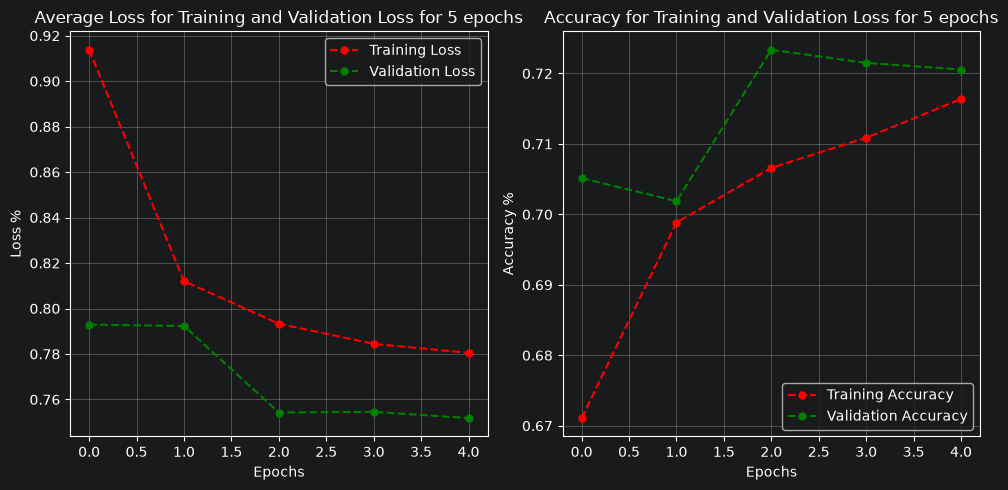

In [64]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(train_loss, 'r.--', markersize=10, label='Training Loss')
axs[0].plot(val_loss, 'g.--', markersize=10, label='Validation Loss')
axs[0].set_title("Average Loss for Training and Validation Loss for 5 epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss %")
axs[0].grid()
axs[0].legend()

axs[1].plot(train_acc, 'r.--', markersize=10, label='Training Accuracy')
axs[1].plot(val_acc, 'g.--', markersize=10, label='Validation Accuracy')
axs[1].set_title("Accuracy for Training and Validation Loss for 5 epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy %")
axs[1].grid()
axs[1].legend()

plt.tight_layout()
plt.show()